# Inverse design TC bằng Basic GNN: prototype substitution + CHGNet + Top 20

**Target: TC = 0.8 W m⁻¹ K⁻¹ tại 300 K**

Notebook này là pipeline độc lập chỉ dành cho **Basic GNN**:

1. Đặt `TARGET_TC = 0.8` và `TARGET_TEMPERATURE = 300 K`.
2. Khôi phục composition–temperature–TC từ graph archive của Basic GNN.
3. Huấn luyện composition proxy để tiền xếp hạng chemical composition.
4. Sinh candidate bằng constrained elemental substitution trên các prototype
   CIF thermoelectric đã biết; giới hạn nguyên tố theo miền training và loại
   composition đã biết khi có thể.
5. Chọn tối đa 20 candidate theo proxy error và composition OOD distance.
6. Sinh CIF, scale lattice theo bán kính cộng hóa trị và relax bằng CHGNet.
7. Dự đoán TC của relaxed CIF bằng checkpoint Basic GNN.
8. Xếp hạng final tối đa 20 candidates chỉ theo
   `model_abs_error = |TC_predicted - TC_target|` tăng dần.

> Prototype substitution và CHGNet relaxation là các bước sàng lọc cấu trúc,
> không chứng minh vật liệu bền nhiệt động học. Các candidate tốt nhất vẫn cần
> được xác nhận bằng formation energy, energy above hull, phonon, DFT hoặc thực
> nghiệm.


## Cell 1 — Cài và kiểm tra thư viện

Cell này cài CHGNet và các thư viện cần thiết. Nếu máy đang dùng PyTorch
1.13–2.5 nhưng PyG 2.7, notebook tự hạ PyG xuống 2.6.1 để tránh lỗi không tương
thích khi load graph archive.


In [1]:
import importlib.metadata
import importlib.util
import re
import subprocess
import sys


def pip_install(package, force=False):
    command = [sys.executable, "-m", "pip", "install", "-q"]
    if force:
        command += ["--force-reinstall", "--no-cache-dir"]
    subprocess.check_call(command + [package])


if importlib.util.find_spec("torch") is None:
    pip_install("torch")

import torch


def major_minor(version_text):
    clean = version_text.split("+")[0]
    parts = clean.split(".")
    return tuple(int(re.match(r"\d+", part).group()) for part in parts[:2])


torch_version = major_minor(torch.__version__)
pyg_was_loaded = "torch_geometric" in sys.modules

if importlib.util.find_spec("torch_geometric") is None:
    pyg_requirement = (
        "torch-geometric==2.6.1"
        if torch_version < (2, 6)
        else "torch-geometric"
    )
    pip_install(pyg_requirement)
else:
    pyg_version_text = importlib.metadata.version("torch-geometric")
    pyg_version = major_minor(pyg_version_text)
    if torch_version < (2, 6) and pyg_version >= (2, 7):
        pip_install("torch-geometric==2.6.1", force=True)
        if pyg_was_loaded:
            raise RuntimeError(
                "Đã đổi PyG về 2.6.1. Hãy restart kernel rồi Run All lại notebook."
            )

REQUIRED_PACKAGES = {
    "ase": "ase",
    "pymatgen": "pymatgen",
    "chgnet": "chgnet",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
}
for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        pip_install(package_name)

print("PyTorch:", torch.__version__)
print("PyG:", importlib.metadata.version("torch-geometric"))
print("Đã kiểm tra/cài xong thư viện.")


PyTorch: 2.11.0+cu128
PyG: 2.8.0
Đã kiểm tra/cài xong thư viện.


## Cell 2 — Import và cấu hình

Đặt notebook, checkpoint, graph archive và folder `downloaded_cif_TE` trong cùng thư mục. Cell tự nhận cả filename gốc và filename có hậu tố `(1)` do trình duyệt tạo khi tải trùng file.

In [2]:
from pathlib import Path
from collections import Counter
import json
import math
import random
import re
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
import torch_geometric.typing

from ase.io import read as ase_read
from ase.neighborlist import neighbor_list
from ase.data import covalent_radii

from pymatgen.core import Composition, Element, Structure
from pymatgen.io.cif import CifWriter

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TARGET_TC = 0.8
TARGET_TEMPERATURE = 300.0

BASE_DIR = Path(r"C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited")
REFERENCE_CIF_DIR = BASE_DIR / "downloaded_cif_TE"

def resolve_uploaded_file(candidate_names):
    for name in candidate_names:
        path = BASE_DIR / name
        if path.exists():
            return path
    return BASE_DIR / candidate_names[0]

MODEL_CHECKPOINT = resolve_uploaded_file(['best_basic_gnn_tc_temperature.pt', 'best_basic_gnn_tc_temperature.pt'])
GRAPH_ARCHIVE = resolve_uploaded_file(['basic_gnn_tc_graphs.pt', 'basic_gnn_tc_graphs.pt'])

OUTPUT_DIR = BASE_DIR / "inverse_design_Basic_GNN_Prototype_CHGNet_TC0p8_T300K"
INITIAL_CIF_DIR = OUTPUT_DIR / "initial_cifs"
RELAXED_CIF_DIR = OUTPUT_DIR / "relaxed_cifs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
INITIAL_CIF_DIR.mkdir(parents=True, exist_ok=True)
RELAXED_CIF_DIR.mkdir(parents=True, exist_ok=True)

# Không gian tìm kiếm composition
USER_ALLOWED_ELEMENTS = None
MAX_ELEMENTS_PER_COMPOSITION = 4
MAX_SITES_PER_PROTOTYPE = 120
MAX_MAPPINGS_PER_TEMPLATE = 250
EXCLUDE_KNOWN_COMPOSITIONS = True
TOP_CANDIDATES = 20
STRUCTURES_PER_COMPOSITION = 1
OOD_WEIGHT = 0.05

# CHGNet relaxation
MAX_STRUCTURES_TO_RELAX = TOP_CANDIDATES
RELAX_FMAX = 0.05
RELAX_STEPS = 300
RELAX_CELL = True
MAX_ABS_VOLUME_CHANGE_PERCENT = 50.0

# OOD và relaxation chỉ dùng để chẩn đoán; không cộng penalty vào final rank.

print("MODEL: Basic GNN")
print("DEVICE:", DEVICE)
print("MODEL_CHECKPOINT:", MODEL_CHECKPOINT)
print("GRAPH_ARCHIVE:", GRAPH_ARCHIVE)
print("REFERENCE_CIF_DIR:", REFERENCE_CIF_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


MODEL: Basic GNN
DEVICE: cuda
MODEL_CHECKPOINT: C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited\best_basic_gnn_tc_temperature.pt
GRAPH_ARCHIVE: C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited\basic_gnn_tc_graphs.pt
REFERENCE_CIF_DIR: C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited\downloaded_cif_TE
OUTPUT_DIR: C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited\inverse_design_Basic_GNN_Prototype_CHGNet_TC0p8_T300K


## Cell 3 — Kiểm tra input

Graph archive chỉ chứa tensor graph, không chứa lattice và atomic coordinates. Folder CIF gốc vẫn cần thiết để làm thư viện prototype cho bước sinh cấu trúc.

In [3]:
if not MODEL_CHECKPOINT.exists():
    raise FileNotFoundError(f"Không tìm thấy checkpoint: {MODEL_CHECKPOINT}")
if not GRAPH_ARCHIVE.exists():
    raise FileNotFoundError(f"Không tìm thấy graph archive: {GRAPH_ARCHIVE}")

reference_cif_paths = (
    sorted(REFERENCE_CIF_DIR.rglob("*.cif"))
    if REFERENCE_CIF_DIR.exists() else []
)
if not reference_cif_paths:
    raise FileNotFoundError(
        f"Không tìm thấy CIF trong {REFERENCE_CIF_DIR}. Hãy upload folder "
        "downloaded_cif_TE từng dùng để huấn luyện."
    )

print("Checkpoint Basic GNN: OK")
print("Graph archive: OK")
print("Số prototype CIF:", len(reference_cif_paths))

Checkpoint Basic GNN: OK
Graph archive: OK
Số prototype CIF: 43


## Cell 4 — Khôi phục composition–temperature–TC từ graph archive Basic GNN

`weights_only=False` chỉ dùng cho graph PyG do chính notebook huấn luyện tạo ra. Không load file không tin cậy theo cách này.

In [4]:
def trusted_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


graphs = trusted_torch_load(GRAPH_ARCHIVE, map_location="cpu")
if not isinstance(graphs, (list, tuple)) or len(graphs) == 0:
    raise ValueError("Graph archive không phải list graph hợp lệ.")

proxy_rows = []
for graph_index, graph in enumerate(graphs):
    numbers = np.asarray(graph.numbers.view(-1).cpu(), dtype=int)
    counts = Counter(numbers.tolist())
    element_amounts = {
        Element.from_Z(int(z)).symbol: int(amount)
        for z, amount in counts.items()
    }
    composition = Composition(element_amounts)
    temperature = float(graph.temperature.view(-1)[0].item())
    tc = float(graph.y.view(-1)[0].item())

    proxy_rows.append({
        "graph_index": graph_index,
        "formula": composition.reduced_formula,
        "composition": composition,
        "Temperature (K)": temperature,
        "TC": tc,
    })

proxy_df = pd.DataFrame(proxy_rows)
print("Số graph rows:", len(proxy_df))
print("Số reduced formula:", proxy_df["formula"].nunique())
print("Temperature range:", proxy_df["Temperature (K)"].min(), "->", proxy_df["Temperature (K)"].max())
print("TC range:", proxy_df["TC"].min(), "->", proxy_df["TC"].max())
display(proxy_df.drop(columns="composition").head())

Số graph rows: 701
Số reduced formula: 42
Temperature range: 5.0 -> 1176.092041015625
TC range: 0.2199999988079071 -> 12.470000267028809


,graph_index,formula,Temperature (K),TC
0,0,SnSe,295.0,1.03
1,1,SnSe,346.0,0.89
2,2,SnSe,400.0,0.78
3,3,SnSe,449.0,0.72
4,4,SnSe,500.0,0.67


## Cell 5 — Tạo composition descriptors

Các descriptor chỉ phụ thuộc composition: số nguyên tố, entropy của atomic fractions và các thống kê có trọng số của atomic number, atomic mass, period, group, electronegativity và covalent radius. Temperature được thêm như một biến riêng.

Composition proxy chỉ dùng để giảm không gian tìm kiếm trước khi có CIF; nó không thay thế ba forward model cấu trúc.

In [5]:
ELEMENT_PROPERTY_NAMES = [
    "atomic_number",
    "atomic_mass",
    "period",
    "group",
    "electronegativity",
    "covalent_radius",
]


def safe_float(value, default=0.0):
    try:
        if value is None:
            return float(default)
        result = float(value)
        return result if np.isfinite(result) else float(default)
    except Exception:
        return float(default)


def element_property_vector(element):
    return np.array([
        float(element.Z),
        safe_float(element.atomic_mass),
        safe_float(element.row),
        safe_float(element.group),
        safe_float(element.X),
        safe_float(covalent_radii[element.Z]),
    ], dtype=float)


def composition_feature_dict(composition, temperature):
    composition = Composition(composition)
    fractional = composition.fractional_composition
    elements = list(fractional.elements)
    fractions = np.array([fractional[element] for element in elements], dtype=float)
    property_matrix = np.vstack([element_property_vector(element) for element in elements])

    features = {
        "Temperature (K)": float(temperature),
        "n_elements": float(len(elements)),
        "fraction_entropy": float(-np.sum(fractions * np.log(fractions + 1e-12))),
        "fraction_max": float(fractions.max()),
        "fraction_min": float(fractions.min()),
        "fraction_l2": float(np.sqrt(np.sum(fractions ** 2))),
    }

    for column_index, property_name in enumerate(ELEMENT_PROPERTY_NAMES):
        values = property_matrix[:, column_index]
        weighted_mean = np.sum(fractions * values)
        weighted_std = np.sqrt(np.sum(fractions * (values - weighted_mean) ** 2))
        features[f"{property_name}_mean"] = float(weighted_mean)
        features[f"{property_name}_std"] = float(weighted_std)
        features[f"{property_name}_min"] = float(values.min())
        features[f"{property_name}_max"] = float(values.max())
        features[f"{property_name}_range"] = float(values.max() - values.min())

    return features


proxy_feature_rows = [
    composition_feature_dict(row.composition, row["Temperature (K)"])
    for _, row in proxy_df.iterrows()
]
proxy_X_df = pd.DataFrame(proxy_feature_rows)
PROXY_FEATURE_COLUMNS = proxy_X_df.columns.tolist()
proxy_X = proxy_X_df.to_numpy(dtype=np.float32)
proxy_y = proxy_df["TC"].to_numpy(dtype=np.float32)

if not np.isfinite(proxy_X).all():
    raise ValueError("Composition features chứa NaN/inf.")

print("Proxy feature count:", len(PROXY_FEATURE_COLUMNS))
display(proxy_X_df.head())

Proxy feature count: 36


,Temperature (K),n_elements,fraction_entropy,fraction_max,fraction_min,fraction_l2,atomic_number_mean,atomic_number_std,atomic_number_min,atomic_number_max,...,electronegativity_mean,electronegativity_std,electronegativity_min,electronegativity_max,electronegativity_range,covalent_radius_mean,covalent_radius_std,covalent_radius_min,covalent_radius_max,covalent_radius_range
0,295.0,2.0,0.693147,0.5,0.5,0.707107,42.0,8.0,34.0,50.0,...,2.255,0.295,1.96,2.55,0.59,1.295,0.095,1.2,1.39,0.19
1,346.0,2.0,0.693147,0.5,0.5,0.707107,42.0,8.0,34.0,50.0,...,2.255,0.295,1.96,2.55,0.59,1.295,0.095,1.2,1.39,0.19
2,400.0,2.0,0.693147,0.5,0.5,0.707107,42.0,8.0,34.0,50.0,...,2.255,0.295,1.96,2.55,0.59,1.295,0.095,1.2,1.39,0.19
3,449.0,2.0,0.693147,0.5,0.5,0.707107,42.0,8.0,34.0,50.0,...,2.255,0.295,1.96,2.55,0.59,1.295,0.095,1.2,1.39,0.19
4,500.0,2.0,0.693147,0.5,0.5,0.707107,42.0,8.0,34.0,50.0,...,2.255,0.295,1.96,2.55,0.59,1.295,0.095,1.2,1.39,0.19


## Cell 6 — Đánh giá và fit composition proxy

GroupKFold chia theo reduced formula để cùng một formula ở nhiều nhiệt độ không xuất hiện đồng thời trong train và validation. Composition proxy chỉ sàng lọc trước khi có CIF; checkpoint GNN mới là model đánh giá cuối.

In [6]:
groups = proxy_df["formula"].astype(str).to_numpy()
n_unique_groups = len(np.unique(groups))
n_splits = min(5, n_unique_groups)
if n_splits < 2:
    raise ValueError("Cần ít nhất 2 formula để đánh giá composition proxy.")

group_cv = GroupKFold(n_splits=n_splits)
cv_rows = []
for fold, (train_idx, valid_idx) in enumerate(
    group_cv.split(proxy_X, proxy_y, groups), start=1
):
    fold_model = ExtraTreesRegressor(
        n_estimators=400,
        max_features=0.80,
        min_samples_leaf=2,
        random_state=SEED + fold,
        n_jobs=-1,
    )
    fold_model.fit(proxy_X[train_idx], proxy_y[train_idx])
    pred = fold_model.predict(proxy_X[valid_idx])
    cv_rows.append({
        "Fold": fold,
        "R2": r2_score(proxy_y[valid_idx], pred),
        "RMSE": mean_squared_error(proxy_y[valid_idx], pred) ** 0.5,
        "MAE": mean_absolute_error(proxy_y[valid_idx], pred),
        "n_valid": len(valid_idx),
        "n_valid_formula": len(np.unique(groups[valid_idx])),
    })

proxy_cv_df = pd.DataFrame(cv_rows)
display(proxy_cv_df.round(4))
display(
    proxy_cv_df[["R2", "RMSE", "MAE"]]
    .mean().to_frame("mean").T.round(4)
)

composition_proxy = ExtraTreesRegressor(
    n_estimators=800,
    max_features=0.80,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
)
composition_proxy.fit(proxy_X, proxy_y)

proxy_scaler = StandardScaler().fit(proxy_X)
proxy_X_scaled = proxy_scaler.transform(proxy_X)
proxy_nearest_neighbor = NearestNeighbors(n_neighbors=1).fit(proxy_X_scaled)

# Ngưỡng OOD lấy từ khoảng cách tới hàng xóm khác gần nhất trong training.
unique_proxy_scaled = np.unique(np.round(proxy_X_scaled, 8), axis=0)
if len(unique_proxy_scaled) >= 2:
    training_nn = NearestNeighbors(n_neighbors=2).fit(unique_proxy_scaled)
    training_nn_distances = training_nn.kneighbors(
        unique_proxy_scaled, return_distance=True
    )[0][:, 1]
    COMPOSITION_OOD_THRESHOLD = float(
        np.quantile(training_nn_distances, 0.95)
    )
else:
    COMPOSITION_OOD_THRESHOLD = np.inf

proxy_cv_df.to_csv(
    OUTPUT_DIR / "composition_proxy_group_cv.csv", index=False
)
print("Composition OOD threshold:", COMPOSITION_OOD_THRESHOLD)

,Fold,R2,RMSE,MAE,n_valid,n_valid_formula
0,1,-0.2025,1.8275,1.3949,141,8
1,2,-0.5621,3.2520,2.4256,140,8
2,3,-0.0364,2.5694,1.9014,140,9
3,4,0.1810,3.2561,2.0054,140,9
4,5,0.3411,0.9201,0.5814,140,8


,R2,RMSE,MAE
mean,-0.0558,2.365,1.6617


Composition OOD threshold: 0.47551560401916504


## Cell 7 — Đọc prototype CIF và xác định miền nguyên tố

Framework không sinh một lattice tuỳ ý từ formula. Nó lấy các CIF có thật làm prototype, sau đó thay thế các vai trò nguyên tố và scale thể tích ban đầu theo covalent radius trước relaxation. Cách này giữ được symmetry/topology hợp lý hơn random placement.

In [7]:
template_records = []
template_failures = []

for cif_path in tqdm(reference_cif_paths, desc="Reading prototypes"):
    try:
        structure = Structure.from_file(cif_path)
        if not structure.is_ordered:
            raise ValueError("disordered/partial occupancy")
        roles = sorted(structure.symbol_set)
        if not (2 <= len(roles) <= MAX_ELEMENTS_PER_COMPOSITION):
            continue
        if len(structure) > MAX_SITES_PER_PROTOTYPE:
            continue
        template_records.append({
            "template_path": str(cif_path),
            "template_name": cif_path.stem,
            "structure": structure,
            "roles": roles,
            "template_formula": structure.composition.reduced_formula,
            "n_sites": len(structure),
        })
    except Exception as error:
        template_failures.append({"path": str(cif_path), "error": str(error)})

if not template_records:
    raise ValueError("Không có ordered prototype CIF phù hợp sau khi lọc.")

observed_elements = sorted({
    element.symbol
    for composition in proxy_df["composition"]
    for element in composition.elements
})
allowed_elements = sorted(set(USER_ALLOWED_ELEMENTS or observed_elements))

invalid_symbols = [symbol for symbol in allowed_elements if not Element.is_valid_symbol(symbol)]
if invalid_symbols:
    raise ValueError(f"Ký hiệu nguyên tố không hợp lệ: {invalid_symbols}")

print("Prototype hợp lệ:", len(template_records))
print("Observed elements:", observed_elements)
print("Allowed elements:", allowed_elements)
print("Prototype failures:", len(template_failures))
display(pd.DataFrame([
    {key: value for key, value in record.items() if key != "structure"}
    for record in template_records
]).head())

Reading prototypes:   0%|          | 0/43 [00:00<?, ?it/s]

Prototype hợp lệ: 43
Observed elements: ['Ag', 'As', 'Ba', 'Bi', 'Ca', 'Cd', 'Co', 'Cr', 'Cu', 'Eu', 'Fe', 'Ga', 'Ge', 'In', 'La', 'Li', 'Mg', 'Mo', 'O', 'Pb', 'Ru', 'S', 'Sb', 'Se', 'Si', 'Sn', 'Te', 'Ti', 'Tl', 'Tm', 'Yb', 'Zn']
Allowed elements: ['Ag', 'As', 'Ba', 'Bi', 'Ca', 'Cd', 'Co', 'Cr', 'Cu', 'Eu', 'Fe', 'Ga', 'Ge', 'In', 'La', 'Li', 'Mg', 'Mo', 'O', 'Pb', 'Ru', 'S', 'Sb', 'Se', 'Si', 'Sn', 'Te', 'Ti', 'Tl', 'Tm', 'Yb', 'Zn']
Prototype failures: 0


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymatgen\io\cif.py:1817: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymatgen\io\cif.py:1817: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymatgen\io\cif.py:1817: UserWarning: Issues encountered while parsing CIF: 16 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymatgen\io\cif.py:1817: UserWarning: Issues

,template_path,template_name,roles,template_formula,n_sites
0,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,mp-1069042_Eu(ZnSb)2,"[Eu, Sb, Zn]",Eu(ZnSb)2,5
1,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,mp-1196139_Mg3Sb2,"[Mg, Sb]",Mg3Sb2,40
2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,mp-1216671_TmCuTe2,"[Cu, Te, Tm]",TmCuTe2,4
3,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,mp-1219182_SiGe,"[Ge, Si]",SiGe,2
4,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,mp-1222152_Mg2ZnSb2,"[Mg, Sb, Zn]",Mg2ZnSb2,5


## Cell 8 — Sinh, tiền xếp hạng và chọn Top 20 chemical candidates

Notebook sinh các phép thay thế nguyên tố trên prototype CIF đã biết. Candidate
được giới hạn bởi miền nguyên tố của training data, số loại nguyên tố, số site
của prototype và tính duy nhất của tổ hợp `formula–prototype–mapping`.

Composition proxy dự đoán sơ bộ TC tại 300 K. Candidate được sắp xếp theo
`proxy_score = proxy_abs_error + OOD_WEIGHT × composition_OOD_distance`, sau đó
giữ tối đa hai prototype cho cùng một formula và tối đa 20 candidate để sinh
CIF và relax. Đây là bước tiền sàng lọc; final rank vẫn chỉ dùng TC do forward
model dự đoán từ relaxed CIF.


In [8]:
rng = np.random.default_rng(SEED)
known_formulas = set(proxy_df["formula"].astype(str))
candidate_rows = []
seen_candidate_keys = set()

for template_id, record in enumerate(tqdm(template_records, desc="Generating compositions")):
    roles = record["roles"]
    if len(roles) > len(allowed_elements):
        continue

    assignments = [tuple(roles)]
    assignment_set = set(assignments)
    max_possible = math.perm(len(allowed_elements), len(roles))
    target_count = min(MAX_MAPPINGS_PER_TEMPLATE, max_possible)

    while len(assignments) < target_count:
        assignment = tuple(rng.choice(allowed_elements, size=len(roles), replace=False).tolist())
        if assignment not in assignment_set:
            assignment_set.add(assignment)
            assignments.append(assignment)

    old_amounts = record["structure"].composition.get_el_amt_dict()

    for assignment in assignments:
        mapping = dict(zip(roles, assignment))
        new_amounts = {}
        for old_symbol, amount in old_amounts.items():
            new_symbol = mapping[old_symbol]
            new_amounts[new_symbol] = new_amounts.get(new_symbol, 0.0) + float(amount)

        candidate_composition = Composition(new_amounts)
        formula = candidate_composition.reduced_formula
        mapping_json = json.dumps(mapping, sort_keys=True)
        candidate_key = (formula, record["template_path"], mapping_json)
        if candidate_key in seen_candidate_keys:
            continue
        seen_candidate_keys.add(candidate_key)

        candidate_rows.append({
            "template_id": template_id,
            "template_name": record["template_name"],
            "template_path": record["template_path"],
            "template_formula": record["template_formula"],
            "formula": formula,
            "composition": candidate_composition,
            "mapping_json": mapping_json,
            "n_sites": record["n_sites"],
            "is_known_formula": formula in known_formulas,
        })

candidate_df = pd.DataFrame(candidate_rows)
if candidate_df.empty:
    raise ValueError("Không sinh được candidate composition.")

# Lưu toàn bộ candidate vừa sinh trước bước novelty/proxy/OOD screening.
candidate_df.drop(columns="composition").to_csv(
    OUTPUT_DIR / "all_generated_composition_candidates.csv", index=False
)
print("Tổng candidate sinh từ prototype substitution:", len(candidate_df))
print("Số reduced formula duy nhất:", candidate_df["formula"].nunique())

if EXCLUDE_KNOWN_COMPOSITIONS:
    novel_df = candidate_df[~candidate_df["is_known_formula"]].copy()
    if not novel_df.empty:
        candidate_df = novel_df
    else:
        warnings.warn("Không còn novel formula; giữ lại known formula để pipeline tiếp tục.")

candidate_feature_df = pd.DataFrame([
    composition_feature_dict(comp, TARGET_TEMPERATURE)
    for comp in candidate_df["composition"]
])[PROXY_FEATURE_COLUMNS]
candidate_X = candidate_feature_df.to_numpy(dtype=np.float32)

candidate_df["proxy_TC_300K"] = composition_proxy.predict(candidate_X)
candidate_df["proxy_abs_error"] = np.abs(candidate_df["proxy_TC_300K"] - TARGET_TC)
candidate_scaled = proxy_scaler.transform(candidate_X)
candidate_df["composition_OOD_distance"] = proxy_nearest_neighbor.kneighbors(
    candidate_scaled, return_distance=True
)[0].reshape(-1)
candidate_df["proxy_score"] = (
    candidate_df["proxy_abs_error"]
    + OOD_WEIGHT * candidate_df["composition_OOD_distance"]
)

candidate_df = candidate_df.sort_values(
    ["proxy_score", "proxy_abs_error", "composition_OOD_distance"]
).reset_index(drop=True)

# Giữ đa dạng: tối đa STRUCTURES_PER_COMPOSITION prototype cho mỗi formula.
selected_candidates = (
    candidate_df.groupby("formula", sort=False, group_keys=False)
    .head(STRUCTURES_PER_COMPOSITION)
    .head(TOP_CANDIDATES)
    .reset_index(drop=True)
)
selected_candidates.insert(
    0,
    "candidate_id",
    [f"cand_{i:04d}" for i in range(len(selected_candidates))],
)

candidate_df.drop(columns="composition").to_csv(
    OUTPUT_DIR / "composition_candidates_ranked_by_proxy_and_OOD.csv", index=False
)
selected_candidates.drop(columns="composition").to_csv(
    OUTPUT_DIR / "selected_top20_composition_candidates.csv", index=False
)

print("Candidate sau novelty screening:", len(candidate_df))
print("Candidate được chọn để sinh CIF/relax:", len(selected_candidates))
if len(selected_candidates) < TOP_CANDIDATES:
    warnings.warn(
        f"Chỉ có {len(selected_candidates)} candidate để xử lý, "
        f"ít hơn TOP_CANDIDATES={TOP_CANDIDATES}."
    )
display(selected_candidates.drop(columns="composition").head(20))


Generating compositions:   0%|          | 0/43 [00:00<?, ?it/s]

Tổng candidate sinh từ prototype substitution: 10750
Số reduced formula duy nhất: 8364
Candidate sau novelty screening: 10672
Candidate được chọn để sinh CIF/relax: 20


,candidate_id,template_id,template_name,template_path,template_formula,formula,mapping_json,n_sites,is_known_formula,proxy_TC_300K,proxy_abs_error,composition_OOD_distance,proxy_score
0,cand_0000,18,mp-19774_Eu(CdSb)2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,Eu(CdSb)2,Mg2GaSb2,"{""Cd"": ""Sb"", ""Eu"": ""Ga"", ""Sb"": ""Mg""}",5,False,0.843534,0.043534,0.185717,0.052820
1,cand_0001,24,mp-22811_InCuSe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,InCuSe2,TlSbSe2,"{""Cu"": ""Sb"", ""In"": ""Tl"", ""Se"": ""Se""}",8,False,0.800572,0.000572,1.672991,0.084222
2,cand_0002,2,mp-1216671_TmCuTe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,TmCuTe2,Eu2SbAs,"{""Cu"": ""As"", ""Te"": ""Eu"", ""Tm"": ""Sb""}",4,False,0.783289,0.016711,1.388834,0.086153
3,cand_0003,20,mp-20554_InAgSe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,InAgSe2,Tm2GaSb,"{""Ag"": ""Ga"", ""In"": ""Sb"", ""Se"": ""Tm""}",8,False,0.803356,0.003356,1.684690,0.087591
4,cand_0004,21,mp-22261_InCuTe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,InCuTe2,TlCdSe2,"{""Cu"": ""Cd"", ""In"": ""Tl"", ""Te"": ""Se""}",8,False,0.813660,0.013660,1.673162,0.097319
5,cand_0005,41,mp-9257_Yb(CdSb)2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,Yb(CdSb)2,Yb(TmAs)2,"{""Cd"": ""Tm"", ""Sb"": ""As"", ""Yb"": ""Yb""}",5,False,0.798900,0.001100,2.042897,0.103245
6,cand_0006,13,mp-1288145_LaCoO3,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,LaCoO3,EuSO3,"{""Co"": ""S"", ""La"": ""Eu"", ""O"": ""O""}",10,False,0.782333,0.017667,1.715403,0.103437
7,cand_0007,20,mp-20554_InAgSe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,InAgSe2,Cu2PbSe,"{""Ag"": ""Pb"", ""In"": ""Se"", ""Se"": ""Cu""}",8,False,0.768433,0.031567,1.488198,0.105977
8,cand_0008,36,mp-686651_Ca9LaTi10O30,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,Ca9LaTi10O30,Eu10Ru(Se3O10)3,"{""Ca"": ""Se"", ""La"": ""Ru"", ""O"": ""O"", ""Ti"": ""Eu""}",100,False,0.774657,0.025343,1.625548,0.106621
9,cand_0009,20,mp-20554_InAgSe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,InAgSe2,Zn2PbSe,"{""Ag"": ""Pb"", ""In"": ""Se"", ""Se"": ""Zn""}",8,False,0.796417,0.003583,2.075964,0.107381


## Cell 9 — Sinh CIF ban đầu bằng prototype substitution

Mỗi candidate dùng phép thay thế đồng thời các species trên prototype. Thể tích ban đầu được hiệu chỉnh theo tỉ số covalent radius trung bình; tọa độ fractional và hình dạng cell được giữ lại. Đây chỉ là cấu trúc khởi tạo cho relaxation, không phải cấu trúc cân bằng cuối.

In [9]:
def mean_site_covalent_radius(structure, symbol_mapping=None):
    values = []
    for site in structure:
        symbol = site.specie.symbol
        if symbol_mapping is not None:
            symbol = symbol_mapping[symbol]
        values.append(float(covalent_radii[Element(symbol).Z]))
    return float(np.mean(values))


def substituted_structure(template_structure, symbol_mapping):
    structure = template_structure.copy()
    original_mean_radius = mean_site_covalent_radius(structure)
    mapped_mean_radius = mean_site_covalent_radius(structure, symbol_mapping)

    species_mapping = {}
    for site in structure:
        old_species = site.specie
        species_mapping[old_species] = Element(symbol_mapping[old_species.symbol])

    structure.replace_species(species_mapping)

    linear_scale = np.clip(mapped_mean_radius / original_mean_radius, 0.75, 1.35)
    structure.scale_lattice(structure.volume * float(linear_scale ** 3))

    distance_matrix = np.asarray(structure.distance_matrix, dtype=float)
    distance_matrix[distance_matrix < 1e-8] = np.inf
    minimum_distance = float(distance_matrix.min())
    if not np.isfinite(minimum_distance) or minimum_distance < 0.50:
        raise ValueError(f"Khoảng cách atom ban đầu không hợp lệ: {minimum_distance:.3f} Å")

    return structure, float(linear_scale), minimum_distance


initial_manifest = []
initial_failures = []

for _, row in tqdm(selected_candidates.iterrows(), total=len(selected_candidates), desc="Writing initial CIFs"):
    try:
        template = template_records[int(row["template_id"])]["structure"]
        mapping = json.loads(row["mapping_json"])
        structure, linear_scale, minimum_distance = substituted_structure(template, mapping)

        safe_formula = re.sub(r"[^A-Za-z0-9_.-]+", "_", row["formula"])
        output_path = INITIAL_CIF_DIR / f"{row['candidate_id']}__{safe_formula}.cif"
        CifWriter(structure, symprec=None).write_file(output_path)

        initial_manifest.append({
            **row.drop(labels=["composition"]).to_dict(),
            "initial_cif_path": str(output_path),
            "initial_formula_check": structure.composition.reduced_formula,
            "initial_volume": float(structure.volume),
            "initial_min_distance": minimum_distance,
            "initial_lattice_scale": linear_scale,
        })
    except Exception as error:
        initial_failures.append({
            "candidate_id": row["candidate_id"],
            "formula": row["formula"],
            "error": str(error),
        })

initial_manifest_df = pd.DataFrame(initial_manifest)
initial_failures_df = pd.DataFrame(initial_failures)
initial_manifest_df.to_csv(OUTPUT_DIR / "initial_cif_manifest.csv", index=False)
if not initial_failures_df.empty:
    initial_failures_df.to_csv(OUTPUT_DIR / "initial_cif_failures.csv", index=False)

print("CIF ban đầu thành công:", len(initial_manifest_df))
print("CIF ban đầu lỗi:", len(initial_failures_df))
display(initial_manifest_df.head())

Writing initial CIFs:   0%|          | 0/20 [00:00<?, ?it/s]

CIF ban đầu thành công: 20
CIF ban đầu lỗi: 0


,candidate_id,template_id,template_name,template_path,template_formula,formula,mapping_json,n_sites,is_known_formula,proxy_TC_300K,proxy_abs_error,composition_OOD_distance,proxy_score,initial_cif_path,initial_formula_check,initial_volume,initial_min_distance,initial_lattice_scale
0,cand_0000,18,mp-19774_Eu(CdSb)2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,Eu(CdSb)2,Mg2GaSb2,"{""Cd"": ""Sb"", ""Eu"": ""Ga"", ""Sb"": ""Mg""}",5,False,0.843534,0.043534,0.185717,0.052820,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,Mg2GaSb2,106.813027,2.579853,0.892670
1,cand_0001,24,mp-22811_InCuSe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,InCuSe2,TlSbSe2,"{""Cu"": ""Sb"", ""In"": ""Tl"", ""Se"": ""Se""}",8,False,0.800572,0.000572,1.672991,0.084222,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,TlSbSe2,208.187453,2.468763,1.019455
2,cand_0002,2,mp-1216671_TmCuTe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,TmCuTe2,Eu2SbAs,"{""Cu"": ""As"", ""Te"": ""Eu"", ""Tm"": ""Sb""}",4,False,0.783289,0.016711,1.388834,0.086153,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,Eu2SbAs,145.353337,2.834269,1.093645
3,cand_0003,20,mp-20554_InAgSe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,InAgSe2,Tm2GaSb,"{""Ag"": ""Ga"", ""In"": ""Sb"", ""Se"": ""Tm""}",8,False,0.803356,0.003356,1.684690,0.087591,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,Tm2GaSb,403.932619,3.174946,1.216319
4,cand_0004,21,mp-22261_InCuTe2,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,InCuTe2,TlCdSe2,"{""Cu"": ""Cd"", ""In"": ""Tl"", ""Te"": ""Se""}",8,False,0.813660,0.013660,1.673162,0.097319,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...,TlCdSe2,215.875886,2.485448,0.961818


## Cell 10 — Relax CIF bằng CHGNet

CHGNet relax cả atomic positions và cell. Cell lưu năng lượng cuối, maximum force cuối và cờ `relax_converged`. CHGNet là ML potential được huấn luyện trên Materials Project trajectories; với candidate quan trọng vẫn cần DFT relaxation để xác nhận.

In [10]:
from chgnet.model import StructOptimizer

if initial_manifest_df.empty:
    raise ValueError("Không có initial CIF để relax.")

relaxer = StructOptimizer(use_device=DEVICE.type)
relax_rows = []
relax_failures = []

relax_input_df = initial_manifest_df.head(MAX_STRUCTURES_TO_RELAX).copy()

for _, row in tqdm(relax_input_df.iterrows(), total=len(relax_input_df), desc="CHGNet relaxation"):
    try:
        initial_structure = Structure.from_file(row["initial_cif_path"])
        result = relaxer.relax(
            initial_structure,
            fmax=RELAX_FMAX,
            steps=RELAX_STEPS,
            relax_cell=RELAX_CELL,
            verbose=False,
            assign_magmoms=False,
        )
        final_structure = result["final_structure"]
        trajectory = result["trajectory"]

        energies = np.asarray(getattr(trajectory, "energies", []), dtype=float)
        final_energy = float(energies[-1]) if energies.size else np.nan

        forces_history = getattr(trajectory, "forces", [])
        if len(forces_history):
            final_forces = np.asarray(forces_history[-1], dtype=float)
            final_max_force = float(np.linalg.norm(final_forces, axis=1).max())
        else:
            final_max_force = np.nan

        safe_formula = re.sub(r"[^A-Za-z0-9_.-]+", "_", row["formula"])
        relaxed_path = RELAXED_CIF_DIR / f"{row['candidate_id']}__{safe_formula}__relaxed.cif"
        CifWriter(final_structure, symprec=None).write_file(relaxed_path)

        relax_rows.append({
            **row.to_dict(),
            "relaxed_cif_path": str(relaxed_path),
            "relaxed_formula_check": final_structure.composition.reduced_formula,
            "relaxed_volume": float(final_structure.volume),
            "volume_change_percent": 100.0 * (
                final_structure.volume - float(row["initial_volume"])
            ) / float(row["initial_volume"]),
            "final_total_energy_eV": final_energy,
            "final_energy_per_atom_eV": final_energy / len(final_structure) if np.isfinite(final_energy) else np.nan,
            "final_max_force_eV_per_A": final_max_force,
            "relax_converged": bool(np.isfinite(final_max_force) and final_max_force <= RELAX_FMAX * 1.05),
        })
    except Exception as error:
        relax_failures.append({
            "candidate_id": row["candidate_id"],
            "formula": row["formula"],
            "error": str(error),
        })

relax_df = pd.DataFrame(relax_rows)
relax_failures_df = pd.DataFrame(relax_failures)
relax_df.to_csv(OUTPUT_DIR / "relaxation_manifest.csv", index=False)
if not relax_failures_df.empty:
    relax_failures_df.to_csv(OUTPUT_DIR / "relaxation_failures.csv", index=False)

print("Relax thành công:", len(relax_df))
print("Relax lỗi:", len(relax_failures_df))
if not relax_df.empty:
    display(relax_df[[
        "candidate_id", "formula", "relax_converged",
        "final_max_force_eV_per_A", "final_energy_per_atom_eV",
        "volume_change_percent", "relaxed_cif_path"
    ]])

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda


CHGNet relaxation:   0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymatgen\io\cif.py:1817: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return parser.parse_structures(primitive=primitive)[0]
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\chgnet\model\model.py:898: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  volumes = torch.tensor(volumes, dtype=TORCH_DTYPE, device=atomic_numbers.device)
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pymatgen\io\cif.py:1817: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  return 

Relax thành công: 20
Relax lỗi: 0


,candidate_id,formula,relax_converged,final_max_force_eV_per_A,final_energy_per_atom_eV,volume_change_percent,relaxed_cif_path
0,cand_0000,Mg2GaSb2,True,0.040026,-3.125808,25.644180,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
1,cand_0001,TlSbSe2,True,0.024898,-3.870211,51.128079,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
2,cand_0002,Eu2SbAs,False,0.058184,-8.265853,-4.533036,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
3,cand_0003,Tm2GaSb,True,0.025908,-4.059023,-24.967877,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
4,cand_0004,TlCdSe2,True,0.028936,-3.210422,25.960793,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
5,cand_0005,Yb(TmAs)2,True,0.026380,-5.223959,-22.587018,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
6,cand_0006,EuSO3,True,0.036191,-8.335425,47.185581,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
7,cand_0007,Cu2PbSe,True,0.000731,-3.876161,-27.969558,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
8,cand_0008,Eu10Ru(Se3O10)3,False,0.064299,-8.059641,48.750387,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
9,cand_0009,Zn2PbSe,True,0.020422,-2.698607,2.553601,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...


## Cell 11 — Graph builder và kiến trúc Basic GNN

Cell này sao chép đúng graph construction và model class từ notebook huấn luyện được cung cấp. Cấu hình checkpoint: hidden_dim=64, 3 GCN layers, mlp_hidden_dim=128, dropout=0.10.

In [11]:
R_CUT = 6.0
MAX_NEIGHBORS = 12


def atoms_to_graph(atoms, temperature, r_cut=6.0, max_neighbors=12):
    center, neighbor, distance = neighbor_list(
        "ijd", atoms, cutoff=r_cut, self_interaction=False
    )
    if len(center) == 0:
        raise ValueError("Không tìm được nguyên tử lân cận trong bán kính cắt")

    center = np.asarray(center)
    neighbor = np.asarray(neighbor)
    distance = np.asarray(distance)
    if max_neighbors is not None:
        keep = []
        for atom_index in np.unique(center):
            positions = np.where(center == atom_index)[0]
            nearest = positions[np.argsort(distance[positions])[:max_neighbors]]
            keep.extend(nearest.tolist())
        keep = np.asarray(keep, dtype=int)
        center = center[keep]
        neighbor = neighbor[keep]
        distance = distance[keep]

    return Data(
        numbers=torch.tensor(atoms.get_atomic_numbers(), dtype=torch.long),
        edge_index=torch.tensor(np.vstack([center, neighbor]), dtype=torch.long),
        edge_length=torch.tensor(distance, dtype=torch.float32),
        temperature=torch.tensor([float(temperature)], dtype=torch.float32),
        num_nodes=len(atoms),
    )


class BasicGNNWithTemperature(nn.Module):
    def __init__(
        self,
        num_atom_types=119,
        hidden_dim=64,
        num_gnn_layers=3,
        mlp_hidden_dim=128,
        dropout=0.10,
    ):
        super().__init__()
        self.atom_embedding = nn.Embedding(num_atom_types, hidden_dim)
        self.convs = nn.ModuleList([
            GCNConv(hidden_dim, hidden_dim) for _ in range(num_gnn_layers)
        ])
        self.norms = nn.ModuleList([
            nn.BatchNorm1d(hidden_dim) for _ in range(num_gnn_layers)
        ])
        self.dropout = dropout
        self.fc1 = nn.Linear(hidden_dim + 1, mlp_hidden_dim)
        self.fc2 = nn.Linear(mlp_hidden_dim, mlp_hidden_dim // 2)
        self.fc_out = nn.Linear(mlp_hidden_dim // 2, 1)

    def forward(self, batch):
        x = self.atom_embedding(batch.numbers)
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, batch.edge_index)
            x = norm(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        graph_features = global_mean_pool(x, batch.batch)
        temperature = batch.temperature.view(-1, 1).to(graph_features.device)
        features = torch.cat([graph_features, temperature], dim=1)
        features = F.relu(self.fc1(features))
        features = F.dropout(features, p=self.dropout, training=self.training)
        features = F.relu(self.fc2(features))
        return self.fc_out(features).view(-1)

## Cell 12 — Load checkpoint Basic GNN

`load_state_dict` dùng strict compatibility. Nếu số convolution hoặc hidden dimension không khớp checkpoint, notebook sẽ dừng thay vì dự đoán bằng weight thiếu.

In [12]:
def load_state_dict_file(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


model = BasicGNNWithTemperature(num_atom_types=119, hidden_dim=64, num_gnn_layers=3, mlp_hidden_dim=128, dropout=0.10).to(DEVICE)
model.load_state_dict(load_state_dict_file(MODEL_CHECKPOINT))
model.eval()

print(model)
print("Load checkpoint thành công.")
print("Architecture: hidden_dim=64, 3 GCN layers, mlp_hidden_dim=128, dropout=0.10")

BasicGNNWithTemperature(
  (atom_embedding): Embedding(119, 64)
  (convs): ModuleList(
    (0-2): 3 x GCNConv(64, 64)
  )
  (norms): ModuleList(
    (0-2): 3 x BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (fc1): Linear(in_features=65, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)
Load checkpoint thành công.
Architecture: hidden_dim=64, 3 GCN layers, mlp_hidden_dim=128, dropout=0.10


## Cell 13 — Xây dựng graph-domain bounds từ training archive

Candidate graph được so với training graph theo số atom, số nguyên tố, mean degree và thống kê edge length. `graph_OOD_count` là số đặc trưng vượt khỏi min–max training.

In [13]:
GRAPH_SUMMARY_COLUMNS = [
    "n_atoms",
    "n_elements",
    "mean_degree",
    "edge_length_mean",
    "edge_length_std",
    "edge_length_min",
    "edge_length_max",
]


def graph_summary(graph):
    numbers = graph.numbers.view(-1).detach().cpu().numpy()
    edge_length = graph.edge_length.view(-1).detach().cpu().numpy()
    n_atoms = int(len(numbers))
    n_edges = int(graph.edge_index.shape[1])
    return {
        "n_atoms": float(n_atoms),
        "n_elements": float(len(np.unique(numbers))),
        "mean_degree": float(n_edges / max(n_atoms, 1)),
        "edge_length_mean": float(edge_length.mean()),
        "edge_length_std": float(edge_length.std(ddof=0)),
        "edge_length_min": float(edge_length.min()),
        "edge_length_max": float(edge_length.max()),
    }


training_graph_summary_df = pd.DataFrame([
    graph_summary(graph) for graph in graphs
])
graph_feature_min = training_graph_summary_df[GRAPH_SUMMARY_COLUMNS].min()
graph_feature_max = training_graph_summary_df[GRAPH_SUMMARY_COLUMNS].max()

display(pd.DataFrame({
    "training_min": graph_feature_min,
    "training_max": graph_feature_max,
}))

,training_min,training_max
n_atoms,2.000000,100.000000
n_elements,2.000000,4.000000
mean_degree,12.000000,12.000000
edge_length_mean,2.378954,3.948322
edge_length_std,0.390541,0.788660
edge_length_min,1.869652,3.270897
edge_length_max,2.811257,4.810750


## Cell 14 — Dự đoán TC của relaxed CIF bằng Basic GNN

Mỗi CIF được dựng graph đúng như training notebook và chạy tại 300 K. Prediction âm được clip về 0 giống bước evaluate trong notebook gốc.

In [14]:
@torch.no_grad()
def predict_relaxed_cif(cif_path, temperature):
    atoms = ase_read(cif_path)
    graph = atoms_to_graph(
        atoms,
        temperature=temperature,
        r_cut=R_CUT,
        max_neighbors=MAX_NEIGHBORS,
    )
    summary = graph_summary(graph)
    batch = next(iter(
        DataLoader([graph], batch_size=1, shuffle=False)
    )).to(DEVICE)
    raw_prediction = float(model(batch).view(-1)[0].item())
    prediction = max(raw_prediction, 0.0)

    ood_flags = {
        feature: bool(
            summary[feature] < graph_feature_min[feature]
            or summary[feature] > graph_feature_max[feature]
        )
        for feature in GRAPH_SUMMARY_COLUMNS
    }

    return {
        "TC_Basic_GNN": prediction,
        "TC_Basic_GNN_raw": raw_prediction,
        "graph_OOD_count": int(sum(ood_flags.values())),
        "graph_OOD_features": ",".join([
            name for name, flag in ood_flags.items() if flag
        ]),
        **{f"graph_{key}": value for key, value in summary.items()},
    }


if relax_df.empty:
    raise ValueError("Không có relaxed CIF để dự đoán.")

prediction_rows = []
prediction_failures = []
for _, row in tqdm(
    relax_df.iterrows(), total=len(relax_df), desc="Basic GNN prediction"
):
    try:
        prediction = predict_relaxed_cif(
            row["relaxed_cif_path"], TARGET_TEMPERATURE
        )
        prediction_rows.append({**row.to_dict(), **prediction})
    except Exception as error:
        prediction_failures.append({
            "candidate_id": row["candidate_id"],
            "formula": row["formula"],
            "error": str(error),
        })

results_df = pd.DataFrame(prediction_rows)
prediction_failures_df = pd.DataFrame(prediction_failures)
if not prediction_failures_df.empty:
    prediction_failures_df.to_csv(
        OUTPUT_DIR / "forward_prediction_failures.csv", index=False
    )

print("Prediction thành công:", len(results_df))
print("Prediction lỗi:", len(prediction_failures_df))

Basic GNN prediction:   0%|          | 0/20 [00:00<?, ?it/s]

Prediction thành công: 20
Prediction lỗi: 0


## Cell 15 — Final ranking theo sai số TC của Basic GNN

Final rank của tối đa 20 candidates chỉ dựa trên
`model_abs_error = |TC_Basic_GNN - TARGET_TC|`, sắp xếp tăng dần.
Candidate có `final_rank = 1` là candidate có TC do Basic GNN dự đoán gần target
0.8 nhất. Các chỉ số OOD và relaxation được xuất để đánh giá độ tin cậy nhưng
không thay đổi thứ hạng.


In [15]:
if results_df.empty:
    raise ValueError("Không có candidate nào dự đoán thành công.")

# Sai số dùng DUY NHẤT cho final ranking.
results_df["target_TC"] = TARGET_TC
results_df["target_temperature_K"] = TARGET_TEMPERATURE
results_df["model_abs_error"] = np.abs(
    results_df["TC_Basic_GNN"] - results_df["target_TC"]
)

# Các chỉ số dưới đây chỉ để chẩn đoán độ tin cậy, không tham gia final rank.
results_df["composition_OOD_ratio"] = (
    results_df["composition_OOD_distance"]
    / max(COMPOSITION_OOD_THRESHOLD, 1e-12)
)
results_df["passes_composition_domain"] = (
    results_df["composition_OOD_distance"] <= COMPOSITION_OOD_THRESHOLD
)
results_df["passes_graph_domain"] = results_df["graph_OOD_count"] == 0
results_df["passes_relaxation_sanity"] = (
    results_df["relax_converged"].astype(bool)
    & (
        results_df["volume_change_percent"].abs()
        <= MAX_ABS_VOLUME_CHANGE_PERCENT
    )
)
results_df["passes_all_diagnostic_checks"] = (
    results_df["passes_composition_domain"]
    & results_df["passes_graph_domain"]
    & results_df["passes_relaxation_sanity"]
)

# FINAL RANK: chỉ sort theo |TC_predicted - TC_target| từ nhỏ đến lớn.
results_df = results_df.sort_values(
    "model_abs_error",
    ascending=True,
    kind="mergesort",
).head(TOP_CANDIDATES).reset_index(drop=True)
results_df.insert(0, "final_rank", np.arange(1, len(results_df) + 1))

final_results_path = (
    OUTPUT_DIR
    / "inverse_design_Basic_GNN_Prototype_CHGNet_final_top20_ranked_by_TC_error_TC0p8_T300K.csv"
)
results_df.to_csv(final_results_path, index=False)

display_columns = [
    "final_rank", "candidate_id", "formula", "template_formula",
    "TC_Basic_GNN", "target_TC", "model_abs_error",
    "target_temperature_K", "proxy_TC_300K",
    "passes_composition_domain", "passes_graph_domain",
    "passes_relaxation_sanity", "passes_all_diagnostic_checks",
    "composition_OOD_distance", "composition_OOD_ratio",
    "graph_OOD_count", "graph_OOD_features",
    "relax_converged", "final_max_force_eV_per_A",
    "volume_change_percent", "relaxed_cif_path",
]

print("Final ranking criterion: model_abs_error = |TC_predicted - target_TC|")
print("Final CSV:", final_results_path)
print("Số candidate được rank:", len(results_df))
print(
    "Số candidate vượt mọi diagnostic check:",
    int(results_df["passes_all_diagnostic_checks"].sum()),
)
print(
    "Best candidate:",
    results_df.loc[0, "formula"],
    "| predicted TC =", results_df.loc[0, "TC_Basic_GNN"],
    "| target TC =", TARGET_TC,
    "| absolute error =", results_df.loc[0, "model_abs_error"],
)
display(results_df[display_columns])


Final ranking criterion: model_abs_error = |TC_predicted - target_TC|
Final CSV: C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited\inverse_design_Basic_GNN_Prototype_CHGNet_TC0p8_T300K\inverse_design_Basic_GNN_Prototype_CHGNet_final_top20_ranked_by_TC_error_TC0p8_T300K.csv
Số candidate được rank: 20
Số candidate vượt mọi diagnostic check: 1
Best candidate: Eu2SbAs | predicted TC = 0.7607383728027344 | target TC = 0.8 | absolute error = 0.03926162719726567


,final_rank,candidate_id,formula,template_formula,TC_Basic_GNN,target_TC,model_abs_error,target_temperature_K,proxy_TC_300K,passes_composition_domain,...,passes_relaxation_sanity,passes_all_diagnostic_checks,composition_OOD_distance,composition_OOD_ratio,graph_OOD_count,graph_OOD_features,relax_converged,final_max_force_eV_per_A,volume_change_percent,relaxed_cif_path
0,1,cand_0002,Eu2SbAs,TmCuTe2,0.760738,0.8,0.039262,300.0,0.783289,False,...,False,False,1.388834,2.920690,1,edge_length_max,False,0.058184,-4.533036,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
1,2,cand_0018,EuAsO2,AgSbTe2,0.723710,0.8,0.076290,300.0,0.821782,False,...,True,False,2.095628,4.407065,0,,True,0.039466,3.727207,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
2,3,cand_0006,EuSO3,LaCoO3,0.709304,0.8,0.090696,300.0,0.782333,False,...,True,False,1.715403,3.607459,1,edge_length_min,True,0.036191,47.185581,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
3,4,cand_0008,Eu10Ru(Se3O10)3,Ca9LaTi10O30,0.681865,0.8,0.118135,300.0,0.774657,False,...,False,False,1.625548,3.418495,1,edge_length_min,False,0.064299,48.750387,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
4,5,cand_0003,Tm2GaSb,InAgSe2,0.940850,0.8,0.140850,300.0,0.803356,False,...,True,False,1.684690,3.542870,2,"edge_length_mean,edge_length_std",True,0.025908,-24.967877,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
5,6,cand_0011,TeAs2Pb,InCuTe2,0.944961,0.8,0.144961,300.0,0.813745,False,...,True,False,1.989803,4.184517,1,edge_length_std,True,0.034824,26.788176,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
6,7,cand_0019,Eu2CuTe,InCuTe2,0.992196,0.8,0.192196,300.0,0.785113,False,...,True,False,2.238648,4.707833,3,"edge_length_mean,edge_length_std,edge_length_max",True,0.002277,-24.101986,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
7,8,cand_0012,Tm2ZnSb,InCuSe2,1.040709,0.8,0.240709,300.0,0.824154,False,...,True,False,1.815908,3.818818,2,"edge_length_mean,edge_length_std",True,0.022774,-18.913362,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
8,9,cand_0005,Yb(TmAs)2,Yb(CdSb)2,1.254874,0.8,0.454874,300.0,0.798900,False,...,True,False,2.042897,4.296173,0,,True,0.026380,-22.587018,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...
9,10,cand_0010,Eu2In2As,Ba(ZnAs)2,1.255393,0.8,0.455393,300.0,0.724427,False,...,True,False,0.648091,1.362923,0,,True,0.027965,-12.661107,C:\Users\Admin\Downloads\final_CGCNN_GNN_model...


## Cell 16 — Vẽ final top 20 đã rank theo sai số TC và đóng gói relaxed CIF

Các cột được hiển thị đúng theo `final_rank`, tức là từ
`|TC_Basic_GNN - 0.8|` nhỏ nhất đến lớn nhất. Đường đứt nét là target 0.8.
Các cờ OOD và relaxation không thay đổi thứ hạng nhưng cần được xem xét khi
chọn candidate để xác nhận bằng DFT hoặc thực nghiệm.


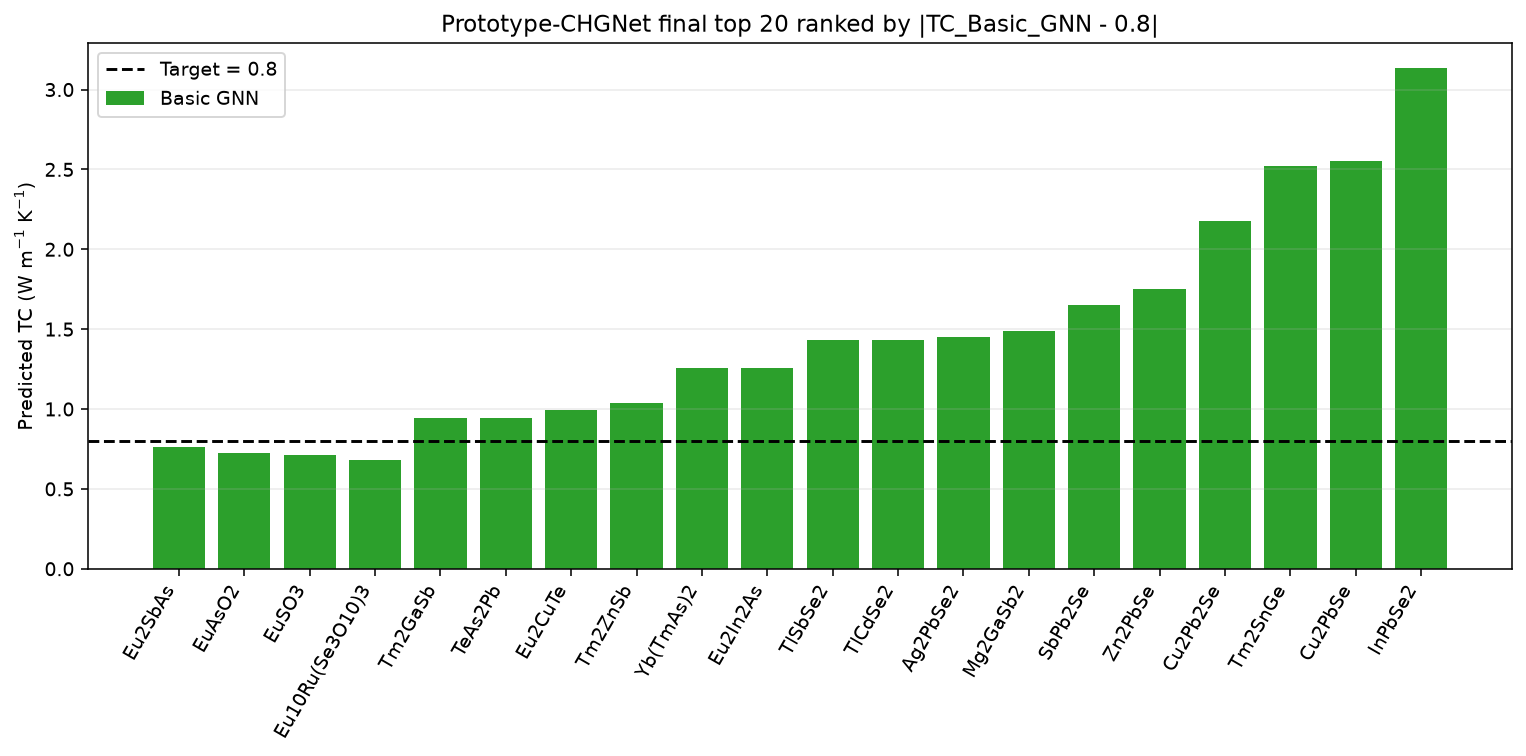

Figure: C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited\inverse_design_Basic_GNN_Prototype_CHGNet_TC0p8_T300K\Prototype_CHGNet_final_top20_ranked_by_TC_error_Basic_GNN.png
Final CSV: C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited\inverse_design_Basic_GNN_Prototype_CHGNet_TC0p8_T300K\inverse_design_Basic_GNN_Prototype_CHGNet_final_top20_ranked_by_TC_error_TC0p8_T300K.csv
Relaxed CIF ZIP: C:\Users\Admin\Downloads\final_CGCNN_GNN_model_for_TE_TC\model_edited\inverse_design_Basic_GNN_Prototype_CHGNet_TC0p8_T300K\Prototype_CHGNet_relaxed_candidate_cifs_Basic_GNN_TC0p8_T300K.zip


In [16]:
plot_df = results_df.head(min(20, len(results_df))).copy()
x = np.arange(len(plot_df))

fig, ax = plt.subplots(
    figsize=(max(10, 0.55 * len(plot_df)), 5.5), dpi=140
)
ax.bar(
    x,
    plot_df["TC_Basic_GNN"],
    color="#2ca02c",
    label="Basic GNN",
)
ax.axhline(
    TARGET_TC,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Target = 0.8",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["formula"], rotation=60, ha="right")
ax.set_ylabel("Predicted TC (W m$^{-1}$ K$^{-1}$)")
ax.set_title("Prototype-CHGNet final top 20 ranked by |TC_Basic_GNN - 0.8|")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()

figure_path = OUTPUT_DIR / "Prototype_CHGNet_final_top20_ranked_by_TC_error_Basic_GNN.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

zip_base = OUTPUT_DIR / "Prototype_CHGNet_relaxed_candidate_cifs_Basic_GNN_TC0p8_T300K"
zip_path = shutil.make_archive(
    str(zip_base), "zip", root_dir=OUTPUT_DIR, base_dir="relaxed_cifs"
)

print("Figure:", figure_path)
print("Final CSV:", final_results_path)
print("Relaxed CIF ZIP:", zip_path)


## Cách đọc kết quả final

- `final_rank`: thứ hạng từ 1 đến tối đa 20, chỉ dựa trên
  `model_abs_error` tăng dần.
- `TC_Basic_GNN`: TC dự đoán từ relaxed CIF bằng Basic GNN.
- `target_TC`: TC mục tiêu, bằng 0.8 W m⁻¹ K⁻¹.
- `model_abs_error`: `|TC_Basic_GNN - target_TC|`; đây là tiêu chí duy nhất tạo
  `final_rank`.
- `proxy_TC_300K`: dự đoán sơ bộ theo composition trước khi có relaxed CIF;
  không dùng cho final rank.
- `composition_OOD_distance` và `graph_OOD_count`: thông tin ngoài miền dữ liệu.
- `passes_relaxation_sanity`: relaxation hội tụ và thể tích không đổi quá 50%.
- `passes_all_diagnostic_checks`: tổng hợp composition domain, graph domain và
  relaxation sanity; không dùng để xếp hạng.
- `final_energy_per_atom_eV`: chỉ theo dõi relaxation, không phải formation
  energy hoặc energy above hull.

Hàng đầu tiên trong CSV là candidate có TC do Basic GNN dự đoán gần 0.8 nhất
trong các candidate dự đoán thành công. Các cột độ tin cậy cần được xem xét khi
quyết định candidate nào tiếp tục xác nhận bằng DFT, phonon hoặc thực nghiệm,
nhưng không thay đổi `final_rank`.
